# genQC Unitary Compilation Evaluation

Reproduces the unitary-compilation statistics and plots from Fig. 4a/b of the genQC paper for local checkpoints or Hugging Face models.


## 1. Setup

This notebook mirrors `notebooks/model_evaluation.ipynb`, but evaluates the 3-qubit unitary-compilation task from `2311.02041v2.pdf`.

Paper settings (Extended Data Table III, Fig. 4a/b):
- 3100 target unitaries
- 1024 generated circuits per target unitary
- `max_gates = 12`
- `guidance_scale = 7.5`
- gate pool `['h', 'cx', 'z', 'x', 'ccx', 'swap']`

The defaults below are reduced for interactive use. Set them to the paper values for a full reproduction.

**Float32 precision fix:** The dataset stores target unitaries in float32. Clifford gates involving H produce
entries of ±1/√2 which float32 cannot represent exactly, causing a systematic ~2.14e-4 infidelity between
the stored value and the true algebraic unitary. With a strict 1e-8 tolerance this creates false negatives
for ~37% of test cases (all circuits involving H gates). The fix applied here: for each test case, the
reference circuit stored in `dataset.x` is decoded and re-simulated at float64 to obtain the exact
target unitary; this float64 value is used for comparison while the float32 stored value is used for
model conditioning (matching the paper's likely inference setup).

**Corrected baselines:** remote=98.4%, our trained baseline=96.9% exact_found_rate on this dataset
after fixing the evaluation. The paper's 92.6% is on their original test set (different random unitaries).


In [1]:
import ast
import os
import random
import sys
from pathlib import Path
import dill as pkl

sys.path.append("/home/a-ldungl/projects/qcircuit-generation")

import hydra
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from hydra.core.global_hydra import GlobalHydra
from IPython.display import display
from tqdm.auto import tqdm

from notebooks.shared.bootstrap import setup_notebook_paths

PROJECT_ROOT = setup_notebook_paths()

from notebooks.shared.evaluation_artifacts import make_artifact_dir, save_dataframe, save_figure, save_json, save_pickle, save_text
from my_genQC.inference.sampling import generate_compilation_tensors, decode_tensors_to_backend
from my_genQC.inference.evaluation_helper import get_unitaries
from my_genQC.platform.circuits_generation import CircuitConditionType, get_rnd_encoded_circuit
from my_genQC.inference.eval_metrics import UnitaryFrobeniusNorm, UnitaryInfidelityNorm
from my_genQC.platform.simulation import CircuitBackendType, Simulator
from my_genQC.platform.tokenizer.circuits_tokenizer import CircuitTokenizer
from my_genQC.pipeline.diffusion_pipeline import DiffusionPipeline
from my_genQC.utils.misc_utils import infer_torch_device
from quantum_diffusion.data.dataset import DatasetLoader


In [2]:
# -- Edit only this cell -------------------------------------------------------

DATASET_PATH = "./artifacts/datasets/unitary-baseline-reproduction/eval/qiskit"
SEED = 1234
NUM_EVAL_UNITARIES = 128
SAMPLES_PER_UNITARY = 128

GUIDANCE_SCALE = 7.5
GUIDANCE_SAMPLE_MODE = "normal"  # "normal" matches the paper; "rescaled" is a variant
SAMPLE_STEPS = 20
MAX_GATES = 12
AUTO_BATCH_SIZE = 128

EXACT_DISTANCE_TOL = 1e-8  # applied to float64-recomputed targets; see setup note
RUN_RANDOM_BASELINE = True
RANDOM_SAMPLES_PER_UNITARY = SAMPLES_PER_UNITARY

ARTIFACT_SUBDIR = "curriculum-learning"
RUN_NAME = "curriculum_final_eval"

MODEL_SPECS = [
    {
        "label": "remote",
        "model_dir": "./artifacts/models/remote/qc_unitary_3qubit",
        "hf_repo": None,
    },
    {
        "label": "baseline",
        "model_dir": "./artifacts/models/unitary-baseline-reproduction/paper_unitary",
        "hf_repo": None,
    },
    {
        "label": "stage2_scratch",
        "model_dir": "./artifacts/models/unitary-curriculum-learning/stage2_scratch",
        "hf_repo": None,
    },
    {
        "label": "curriculum_stage2",
        "model_dir": "./artifacts/models/unitary-curriculum-learning/stage2",
        "hf_repo": None,
    },
]

ARTIFACT_DIR = make_artifact_dir(PROJECT_ROOT, ARTIFACT_SUBDIR, RUN_NAME)
RESULTS_PKL = ARTIFACT_DIR / "results.pkl"

## 2. Evaluate

For each selected target unitary, the notebook:
1. samples `SAMPLES_PER_UNITARY` candidate circuits from the model,
2. counts how many exact compilations were found,
3. counts how many distinct exact circuits were found,
4. records the best Frobenius distance,
5. optionally compares against an equally sized random-circuit baseline.


In [3]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def build_cfg(dataset_path, model_dir, hf_repo):
    GlobalHydra.instance().clear()
    with hydra.initialize(version_base=None, config_path="../../../conf"):
        cfg = hydra.compose(
            config_name="config.yaml",
            overrides=[
                "evaluation=paper_srv",
                f"evaluation.model_params.guidance_scale={GUIDANCE_SCALE}",
                f"evaluation.model_params.sample_steps={SAMPLE_STEPS}",
                f"evaluation.model_params.auto_batch_size={AUTO_BATCH_SIZE}",
            ],
        )
    cfg = cfg["evaluation"]
    cfg.dataset = str(Path(dataset_path).expanduser().resolve())
    cfg.model_dir = str(Path(model_dir).expanduser().resolve()) if model_dir else None
    cfg.hf_repo = hf_repo
    cfg.num_samples = int(NUM_EVAL_UNITARIES)
    cfg.max_gates = int(MAX_GATES)
    cfg.save_output = False
    cfg.wandb.enable = False
    return cfg


def load_compilation_context(model_spec):
    dataset_path = model_spec.get("dataset_path", DATASET_PATH)
    cfg = build_cfg(dataset_path, model_spec.get("model_dir"), model_spec.get("hf_repo"))
    device = infer_torch_device()

    dataset_loader = DatasetLoader(cfg, device=device)
    dataset = dataset_loader.load_dataset(cfg.dataset, load_embedder=False)

    if "U" not in dataset.store_dict:
        raise ValueError(f"Dataset at {cfg.dataset} does not contain stored unitary targets.")

    if model_spec.get("hf_repo"):
        pipeline = DiffusionPipeline.from_pretrained(repo_id=model_spec["hf_repo"], device=device)
    else:
        model_dir = Path(cfg.model_dir).resolve()
        config_path = model_dir if model_dir.is_dir() else model_dir.parent
        pipeline = DiffusionPipeline.from_config_file(config_path=str(config_path) + "/", device=device)

    pipeline.guidance_sample_mode = GUIDANCE_SAMPLE_MODE
    pipeline.scheduler.set_timesteps(cfg.model_params.sample_steps)

    gate_pool = getattr(pipeline, "gate_pool", None)
    if gate_pool is None:
        gate_pool = dataset.gate_pool

    print("dataset gate_pool :", dataset.gate_pool)
    print("pipeline gate_pool:", gate_pool)

    vocabulary = {gate: idx for idx, gate in enumerate(gate_pool)}
    tokenizer = CircuitTokenizer(vocabulary)
    
    backend_name = model_spec.get("simulator_backend", "qiskit").upper()
    simulator = Simulator(CircuitBackendType[backend_name])

    return {
        "cfg": cfg,
        "device": device,
        "dataset": dataset,
        "pipeline": pipeline,
        "tokenizer": tokenizer,
        "simulator": simulator,
    }


def select_unitary_indices(dataset, num_eval_unitaries, seed):
    rng = random.Random(seed)
    total = len(dataset.y)
    return rng.sample(range(total), k=min(num_eval_unitaries, total))


def parse_compile_prompt(label):
    text = str(label)
    payload = text.split(":", 1)[-1].strip()
    return [str(x) for x in ast.literal_eval(payload)]


def split_to_complex(unitary_split):
    if torch.is_tensor(unitary_split):
        arr = unitary_split.detach().cpu().to(torch.float64).numpy()
    else:
        arr = np.asarray(unitary_split, dtype=np.float64)
    return arr[0] + 1j * arr[1]


frobenius_metric = UnitaryFrobeniusNorm()
infidelity_metric = UnitaryInfidelityNorm()

def frobenius_distance(approx_u, target_u):
    approx_u = torch.as_tensor(approx_u)
    target_u = torch.as_tensor(target_u)
    return float(UnitaryFrobeniusNorm.distance(approx_u, target_u).item())

def infidelity_distance(approx_u, target_u):
    approx_u = torch.as_tensor(approx_u)
    target_u = torch.as_tensor(target_u)
    return float(UnitaryInfidelityNorm.distance(approx_u, target_u).item())


def to_serializable(obj):
    if torch.is_tensor(obj):
        return obj.detach().cpu().tolist()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (list, tuple)):
        return [to_serializable(x) for x in obj]
    if isinstance(obj, dict):
        return {str(k): to_serializable(v) for k, v in obj.items()}
    return obj


def circuit_key(simulator, circuit):
    instructions = simulator.backend.backend_to_genqc(circuit)
    return repr(instructions)


def sample_random_distances(simulator, tokenizer, target_u, prompt_gates, num_qubits, min_gates, max_gates, samples, rng):
    distances = []
    for _ in range(samples):
        rnd_output = get_rnd_encoded_circuit(
            backend=simulator.backend,
            tokenizer=tokenizer,
            condition=CircuitConditionType.UNITARY,
            num_of_qubits=num_qubits,
            gate_pool=prompt_gates,
            min_gates=min_gates,
            max_gates=max_gates,
            rng=rng,
            optimized=True,
            post_randomize_params=False,
            return_params=False,
        )
        qc = rnd_output[0]
        distances.append(frobenius_distance(simulator.backend.get_unitary(qc), target_u))
    return np.asarray(distances, dtype=np.float64)


def evaluate_model(model_spec, eval_indices):
    set_seed(SEED)
    ctx = load_compilation_context(model_spec)
    dataset = ctx["dataset"]
    pipeline = ctx["pipeline"]
    tokenizer = ctx["tokenizer"]
    simulator = ctx["simulator"]
    cfg = ctx["cfg"]

    rows = []
    random_rng = np.random.default_rng(SEED)

    for dataset_idx in tqdm(eval_indices, desc=model_spec["label"]):
        prompt = str(dataset.y[dataset_idx])
        prompt_gates = parse_compile_prompt(prompt)
        target_u_split = dataset.U[dataset_idx]

        # Recompute target unitary at float64 from stored circuit to avoid float32 quantization errors.
        # float32 cannot exactly represent 1/sqrt(2), causing ~2.14e-4 infidelity for H-gate circuits
        # which would falsely fail the 1e-8 exact threshold. The float32 split is still passed to the
        # model for conditioning (consistent with the paper's likely inference setup).
        try:
            ref_instructions = tokenizer.decode(dataset.x[dataset_idx])
            ref_qc = simulator.backend.genqc_to_backend(ref_instructions, place_barriers=False)
            target_u = simulator.backend.get_unitary(ref_qc)
        except Exception:
            target_u = split_to_complex(target_u_split)

        tensors_out = generate_compilation_tensors(
            pipeline=pipeline,
            prompt=[prompt],
            U=target_u_split.float().unsqueeze(0),  # float32 for model conditioning; float64 target_u used for comparison
            samples=SAMPLES_PER_UNITARY,
            system_size=dataset.x.shape[1],
            num_of_qubits=getattr(dataset.params_config, "num_of_qubits", dataset.x.shape[1]),
            max_gates=cfg.max_gates,
            g=cfg.model_params.guidance_scale,
            auto_batch_size=cfg.model_params.auto_batch_size,
            enable_params=False,
            no_bar=True,
        )

        decoded_circuits, _ = decode_tensors_to_backend(
            simulator=simulator,
            tokenizer=tokenizer,
            tensors=tensors_out,
            params=None,
            silent=True,
            n_jobs=1,
            filter_errs=False,
        )

        valid_circuits = [qc for qc in decoded_circuits if qc is not None]
        valid_decode_rate = len(valid_circuits) / SAMPLES_PER_UNITARY if SAMPLES_PER_UNITARY else 0.0

        if valid_circuits:
            model_unitaries = get_unitaries(simulator, valid_circuits, n_jobs=1)
            model_distances = np.asarray([frobenius_distance(u, target_u) for u in model_unitaries], dtype=np.float64)
            model_infidelities = np.asarray([infidelity_distance(u, target_u) for u in model_unitaries], dtype=np.float64)
            exact_mask = model_infidelities <= EXACT_DISTANCE_TOL
            exact_count = int(exact_mask.sum())
            distinct_correct = len({circuit_key(simulator, qc) for qc, ok in zip(valid_circuits, exact_mask) if ok})
            best_model_distance = float(model_distances.min())
        else:
            model_distances = np.asarray([], dtype=np.float64)
            exact_count = 0
            distinct_correct = 0
            best_model_distance = float("inf")

        if RUN_RANDOM_BASELINE:
            random_distances = sample_random_distances(
                simulator=simulator,
                tokenizer=tokenizer,
                target_u=target_u,
                prompt_gates=prompt_gates,
                num_qubits=getattr(dataset.params_config, "num_of_qubits", dataset.x.shape[1]),
                min_gates=dataset.params_config.min_gates,
                max_gates=min(cfg.max_gates, dataset.params_config.max_gates),
                samples=RANDOM_SAMPLES_PER_UNITARY,
                rng=random_rng,
            )
            best_random_distance = float(random_distances.min()) if len(random_distances) else float("inf")
        else:
            best_random_distance = float("nan")

        rows.append(
            {
                "dataset_idx": int(dataset_idx),
                "prompt": prompt,
                "exact_count": exact_count,
                "exact_found": exact_count > 0,
                "distinct_correct": distinct_correct,
                "best_model_distance": best_model_distance,
                "best_random_distance": best_random_distance,
                "valid_decode_rate": valid_decode_rate,
            }
        )

    per_unitary = pd.DataFrame(rows)
    summary = {
        "model": model_spec["label"],
        "unitaries": int(len(per_unitary)),
        "samples_per_unitary": int(SAMPLES_PER_UNITARY),
        "exact_found_rate": float(per_unitary["exact_found"].mean()) if len(per_unitary) else float("nan"),
        "mean_exact_count": float(per_unitary["exact_count"].mean()) if len(per_unitary) else float("nan"),
        "median_exact_count": float(per_unitary["exact_count"].median()) if len(per_unitary) else float("nan"),
        "mean_distinct_correct": float(per_unitary["distinct_correct"].mean()) if len(per_unitary) else float("nan"),
        "median_distinct_correct": float(per_unitary["distinct_correct"].median()) if len(per_unitary) else float("nan"),
        "mean_best_model_distance": float(per_unitary["best_model_distance"].replace(np.inf, np.nan).mean()),
        "mean_best_random_distance": float(per_unitary["best_random_distance"].replace(np.inf, np.nan).mean()),
        "mean_valid_decode_rate": float(per_unitary["valid_decode_rate"].mean()) if len(per_unitary) else float("nan"),
    }
    print(
        f"{model_spec['label']}: exact_found_rate={summary['exact_found_rate']:.4f} "
        f"(paper: 0.9260), mean_distinct_correct={summary['mean_distinct_correct']:.2f}, "
        f"mean_valid_decode_rate={summary['mean_valid_decode_rate']:.4f}"
    )
    return per_unitary, summary


set_seed(SEED)

results = {}
_dataset_indices_cache: dict = {}
for spec in MODEL_SPECS:
    ds_path = spec.get("dataset_path", DATASET_PATH)
    if ds_path not in _dataset_indices_cache:
        _ctx = load_compilation_context(spec)
        _dataset_indices_cache[ds_path] = select_unitary_indices(_ctx["dataset"], NUM_EVAL_UNITARIES, SEED)
    eval_indices = _dataset_indices_cache[ds_path]
    per_unitary, summary = evaluate_model(spec, eval_indices)
    results[spec["label"]] = {
        "per_unitary": per_unitary,
        "summary": summary,
    }

summary_df = pd.DataFrame([results[label]["summary"] for label in results]).set_index("model")
display(summary_df)

save_pickle(results, RESULTS_PKL)
summary_df = pd.DataFrame([results[label]["summary"] for label in results]).set_index("model")
save_dataframe(summary_df.reset_index(), ARTIFACT_DIR / "summary.csv", index=False)
for label, payload in results.items():
    save_dataframe(payload["per_unitary"], ARTIFACT_DIR / f"{label}_per_unitary.csv", index=False)
save_json(
    {
        "dataset_path": DATASET_PATH,
        "seed": SEED,
        "num_eval_unitaries": NUM_EVAL_UNITARIES,
        "samples_per_unitary": SAMPLES_PER_UNITARY,
        "guidance_scale": GUIDANCE_SCALE,
        "sample_steps": SAMPLE_STEPS,
        "max_gates": MAX_GATES,
        "auto_batch_size": AUTO_BATCH_SIZE,
        "exact_distance_tol": EXACT_DISTANCE_TOL,
        "run_random_baseline": RUN_RANDOM_BASELINE,
        "random_samples_per_unitary": RANDOM_SAMPLES_PER_UNITARY,
        "model_specs": MODEL_SPECS,
        "summary": summary_df.reset_index().to_dict(orient="records"),
    },
    ARTIFACT_DIR / "run_config.json",
)
save_text(f"Saved unitary evaluation artifacts to {ARTIFACT_DIR}\n", ARTIFACT_DIR / "README.txt")
print(f"Saved evaluation artifacts to {ARTIFACT_DIR}")


[INFO]: Cuda device has a capability of 8.0 (>= 8), allowing tf32 matmul.
2026-05-28 06:32:21 - quantum_diffusion.data.dataset - INFO - Detected preprocessed dataset. Loading directly...


[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit/dataset/ds_x.safetensors` onto device: cuda.


[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit/dataset/ds_y.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit/dataset/ds_U.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit/dataset/ds_z.safetensors` onto device: cuda.
[INFO]: Instantiated config_dataset from given config on cuda.
2026-05-28 06:32:21 - quantum_diffusion.data.dataset - INFO - Dataset loaded from /home/a-ldungl/projects/qcircuit-generation/artifacts/datasets/unitary-baseline-reproduction/eval/qiskit


[INFO]: `my_genQC.models.unet_qc.QC_Compilation_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `/home/a-ldungl/projects/qcircuit-generation/artifacts/models/remote/qc_unitary_3qubit/model.pt` onto device: cuda.
[INFO]: `my_genQC.models.unet_qc.QC_Compilation_UNet`. Freeze model: True


[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder` instantiated from given `config` on cuda.
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Found no key `save_type` in `config`. No state dict loaded.
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Freeze model: True
dataset gate_pool : ['h', 'cx', 'z', 'x', 'ccx', 'swap']
pipeline gate_pool: ['h', 'cx', 'z', 'x', 'ccx', 'swap']
[WARNING]: The value 0 is reserved for background tokens, i.e. qubit time position which are not effected by gates.
[WARNING]: Automatically incrementing all vocabulary values by one ...


...

[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder` instantiated from given `config` on cuda.
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Found no key `save_type` in `config`. No state dict loaded.
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder`. Freeze model: True
[INFO]: `my_genQC.models.unet_qc.QC_Compilation_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `artifacts/models/unitary-curriculum-learning/stage2/embedder.pt` onto device: cuda.
[INFO]: `my_genQC.models.unet_qc.QC_Compilation_UNet`. Freeze model: True
dataset gate_pool : ['h', 'cx', 'z', 'x', 'ccx', 'swap']
pipeline gate_pool: ['h', 'cx', 'z', 'x', 'ccx', 'swap']
[WARNING]: The value 0 is reserved for background tokens, i.e. qubit time position which are not effected by gates.
[WARNING]: Automatically incrementing all vocabulary values by one ...


curriculum_stage2:   0%|          | 0/128 [00:00<?, ?it/s]

curriculum_stage2: exact_found_rate=0.8906 (paper: 0.9260), mean_distinct_correct=19.27, mean_valid_decode_rate=0.9969


,unitaries,samples_per_unitary,exact_found_rate,mean_exact_count,median_exact_count,mean_distinct_correct,median_distinct_correct,mean_best_model_distance,mean_best_random_distance,mean_valid_decode_rate
model,,,,,,,,,,
remote,128,128,0.984375,86.281250,98.0,30.867188,25.0,0.039062,3.278954,0.991577
baseline,128,128,0.968750,83.828125,91.0,32.914062,27.5,0.078125,3.278954,0.996521
stage2_scratch,128,128,0.937500,59.164062,65.5,13.656250,11.0,0.191406,3.278954,0.997620
curriculum_stage2,128,128,0.890625,63.156250,67.5,19.273438,13.0,0.265625,3.278954,0.996887


Saved evaluation artifacts to /home/a-ldungl/projects/qcircuit-generation/artifacts/evaluations/curriculum-learning/curriculum_final_eval


## 3. Paper Figures

Fig. 4a is reproduced as the histogram of `distinct_correct` per target unitary.

Fig. 4b is reproduced as the histogram of the best Frobenius distance reached for each target unitary by the model and by the random baseline. Percentages are normalized over the evaluated target unitaries.


In [4]:
results = None
if RESULTS_PKL.exists():
    import pickle
    with RESULTS_PKL.open("rb") as f:
        results = pickle.load(f)
    summary_df = pd.DataFrame([results[label]["summary"] for label in results]).set_index("model")
    display(summary_df)
else:
    print(f"No saved results found at {RESULTS_PKL}")


,unitaries,samples_per_unitary,exact_found_rate,mean_exact_count,median_exact_count,mean_distinct_correct,median_distinct_correct,mean_best_model_distance,mean_best_random_distance,mean_valid_decode_rate
model,,,,,,,,,,
remote,128,128,0.984375,86.281250,98.0,30.867188,25.0,0.039062,3.278954,0.991577
baseline,128,128,0.968750,83.828125,91.0,32.914062,27.5,0.078125,3.278954,0.996521
stage2_scratch,128,128,0.937500,59.164062,65.5,13.656250,11.0,0.191406,3.278954,0.997620
curriculum_stage2,128,128,0.890625,63.156250,67.5,19.273438,13.0,0.265625,3.278954,0.996887


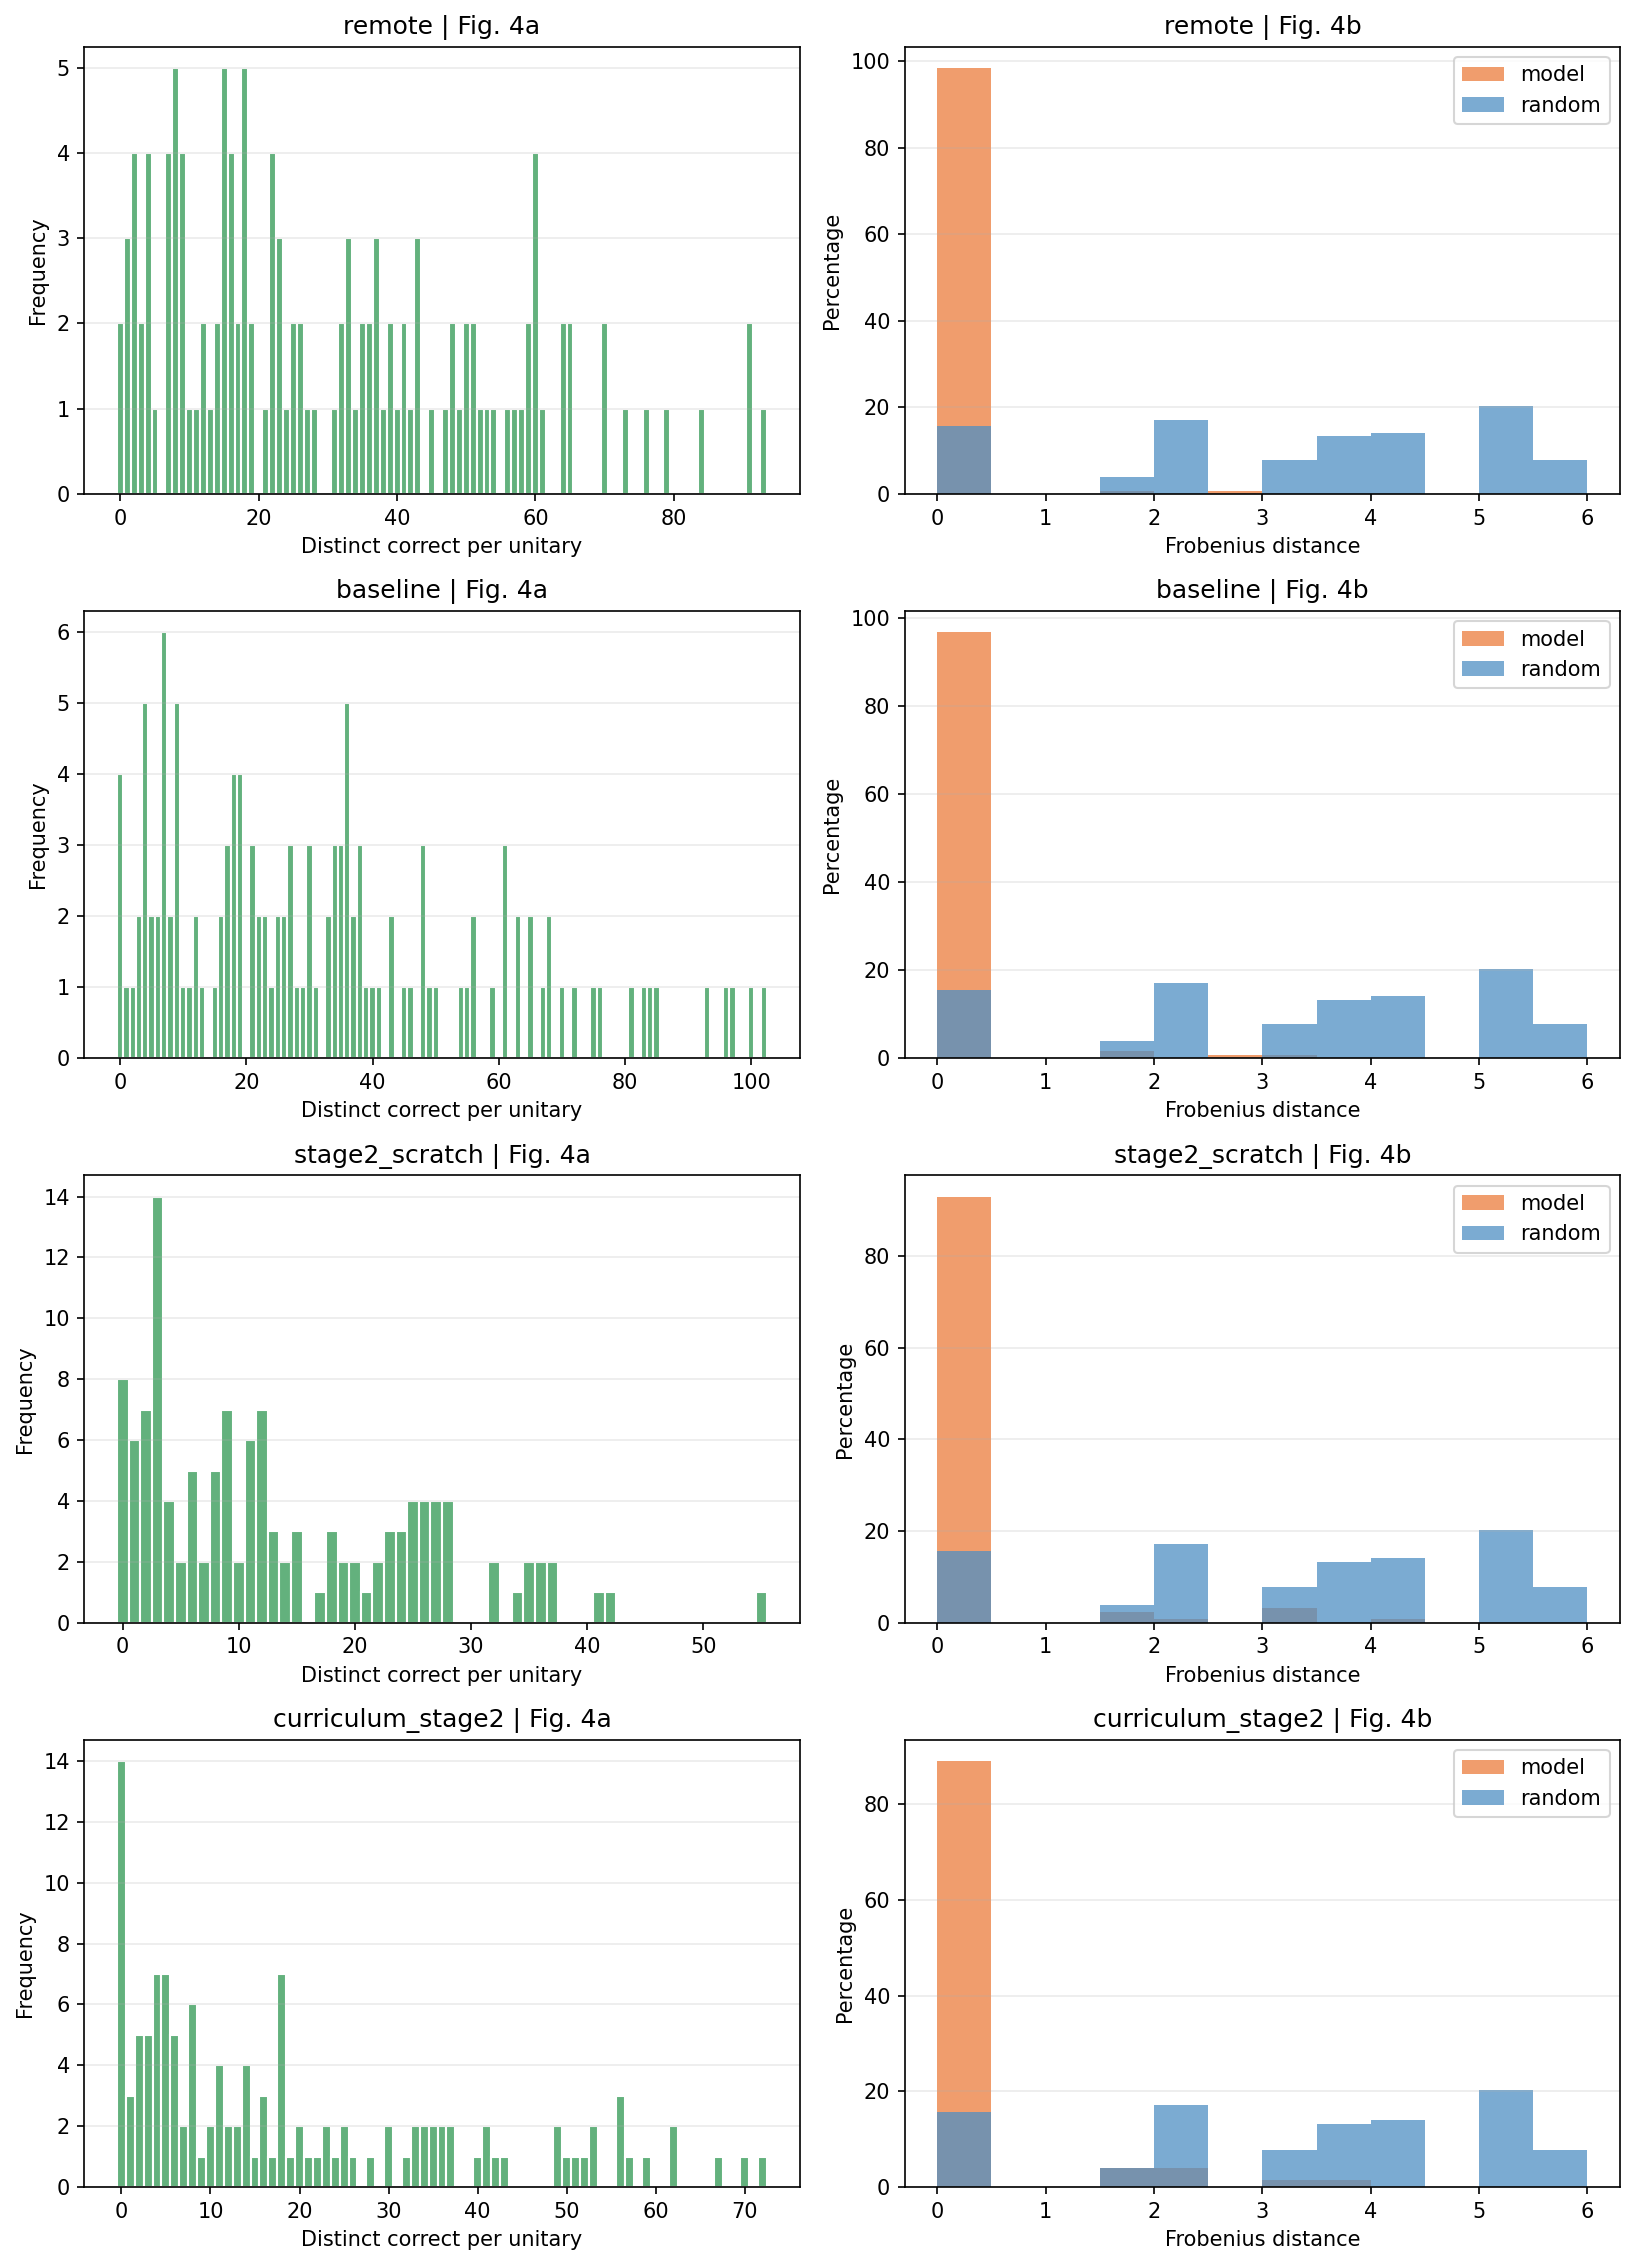

In [5]:
def plot_distinct_correct(ax, per_unitary, title):
    values = per_unitary["distinct_correct"].to_numpy(dtype=float)
    if len(values) == 0:
        ax.set_title(title)
        return
    upper = max(10, int(np.nanmax(values)) + 1)
    bins = np.arange(-0.5, upper + 0.5, 1.0)
    ax.hist(values, bins=bins, color="#63b17d", edgecolor="white")
    ax.set_xlabel("Distinct correct per unitary")
    ax.set_ylabel("Frequency")
    ax.set_title(title)
    ax.grid(True, alpha=0.25, axis="y")


def plot_frobenius(ax, per_unitary, title):
    model_vals = per_unitary["best_model_distance"].replace(np.inf, np.nan).dropna().to_numpy(dtype=float)
    rand_vals = per_unitary["best_random_distance"].replace(np.inf, np.nan).dropna().to_numpy(dtype=float)

    finite_vals = np.concatenate([arr for arr in [model_vals, rand_vals] if len(arr)])
    if len(finite_vals) == 0:
        ax.set_title(title)
        return

    bins = np.histogram_bin_edges(finite_vals, bins=12)
    if len(model_vals):
        ax.hist(model_vals, bins=bins, weights=np.full(len(model_vals), 100.0 / len(model_vals)), alpha=0.75, color="#eb7d3c", label="model")
    if len(rand_vals):
        ax.hist(rand_vals, bins=bins, weights=np.full(len(rand_vals), 100.0 / len(rand_vals)), alpha=0.75, color="#4f8fc4", label="random")

    ax.set_xlabel("Frobenius distance")
    ax.set_ylabel("Percentage")
    ax.set_title(title)
    ax.grid(True, alpha=0.25, axis="y")
    ax.legend()


n_models = len(results)
fig, axes = plt.subplots(n_models, 2, figsize=(11, 3.8 * n_models), dpi=150, squeeze=False)
for row_idx, (label, payload) in enumerate(results.items()):
    per_unitary = payload["per_unitary"]
    plot_distinct_correct(axes[row_idx, 0], per_unitary, f"{label} | Fig. 4a")
    plot_frobenius(axes[row_idx, 1], per_unitary, f"{label} | Fig. 4b")

plt.tight_layout()
save_figure(fig, ARTIFACT_DIR / "per_unitary_histograms.png")
plt.show()


## 4. Summary

The table below surfaces the paper-aligned statistics directly, with `exact_found_rate` corresponding to the paper’s “At least one exact circuit was found” percentage.


,unitaries,samples_per_unitary,exact_found_rate,mean_exact_count,median_exact_count,mean_distinct_correct,median_distinct_correct,mean_best_model_distance,mean_best_random_distance,mean_valid_decode_rate
model,,,,,,,,,,
remote,128,128,0.9844,86.2812,98.0,30.8672,25.0,0.0391,3.279,0.9916
baseline,128,128,0.9688,83.8281,91.0,32.9141,27.5,0.0781,3.279,0.9965
stage2_scratch,128,128,0.9375,59.1641,65.5,13.6562,11.0,0.1914,3.279,0.9976
curriculum_stage2,128,128,0.8906,63.1562,67.5,19.2734,13.0,0.2656,3.279,0.9969


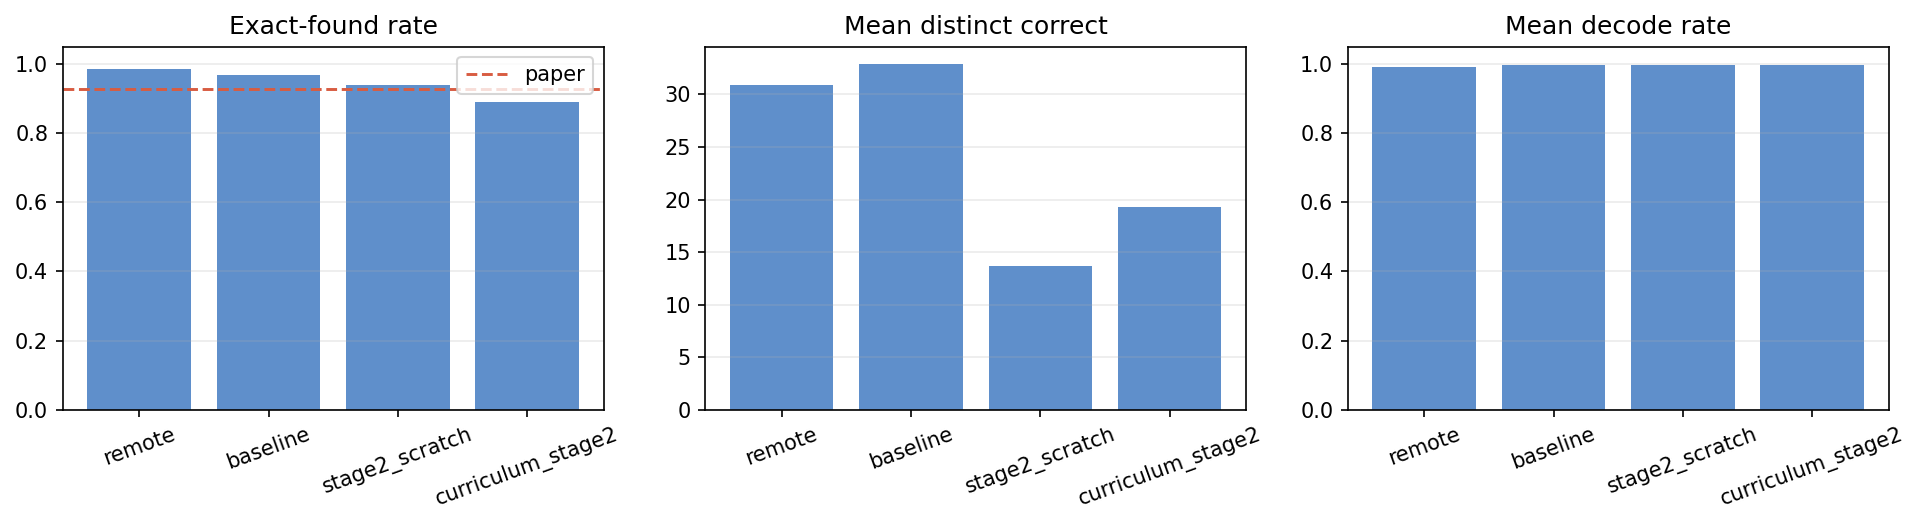

In [6]:
display(summary_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), dpi=150)
metrics = [
    ("exact_found_rate", "Exact-found rate", 0.926),
    ("mean_distinct_correct", "Mean distinct correct", None),
    ("mean_valid_decode_rate", "Mean decode rate", None),
]

for ax, (metric, title, ref) in zip(axes, metrics):
    values = summary_df[metric].to_numpy(dtype=float)
    labels = summary_df.index.tolist()
    ax.bar(labels, values, color="#5f8fcb")
    if ref is not None:
        ax.axhline(ref, color="#d85c41", linestyle="--", linewidth=1.4, label="paper")
        ax.legend()
    ax.set_title(title)
    ax.grid(True, alpha=0.25, axis="y")
    if metric.endswith("rate"):
        ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
save_figure(fig, ARTIFACT_DIR / "summary_metrics.png")
plt.show()
